# Filters and Edge Detection.
Following: 
1. https://docs.opencv.org/3.4/d5/db5/tutorial_laplace_operator.html
2. https://pyimagesearch.com/2021/04/28/opencv-smoothing-and-blurring/
3. https://docs.opencv.org/3.4/d2/d2c/tutorial_sobel_derivatives.html
4. https://docs.opencv.org/4.x/d4/d13/tutorial_py_filtering.html

Acknowlegement: Image by Tomascastelazo, CC BY-SA 3.0 <https://creativecommons.org/licenses/by-sa/3.0>, via Wikimedia Commons

In [2]:
%pip install matplotlib
%pip install opencv-python
%pip install numpy


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import sys
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [4]:
## Function to display image using Matplotlib
def display_image(image1, strng):
    image = cv2.cvtColor(image1, cv2.COLOR_BGR2RGB) ##BGR to RGB conversion for display using Matplotlib
    plt.title(strng)
    plt.imshow(image)
    plt.show()


## Read Image

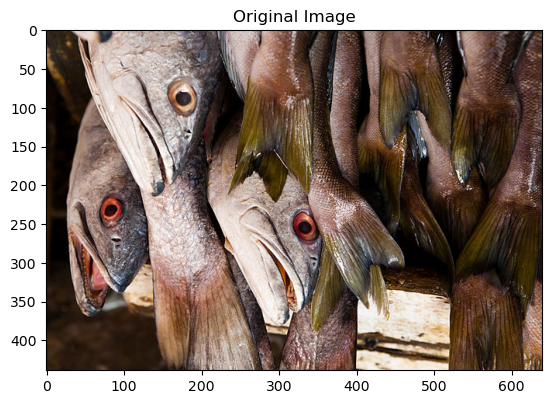

In [5]:
img = cv2.imread("fish.jpg")
img2 = img.copy()
display_image(img, "Original Image")

## Blurring Image
Gaussian blurring is done with the function, cv.GaussianBlur(). We need to specify the width and height of the kernel which is ideally positive and odd. We also should specify the standard deviation in the X and Y directions, sigmaX and sigmaY respectively. If only sigmaX is specified, sigmaY is taken as the same as sigmaX. If both are given as zeros, they are calculated from the kernel size. Gaussian blurring is highly effective in removing Gaussian noise from an image.

To learn about this function, check OpenCV documentation [here](https://docs.opencv.org/4.x/d4/d86/group__imgproc__filter.html#gae8bdcd9154ed5ca3cbc1766d960f45c1)



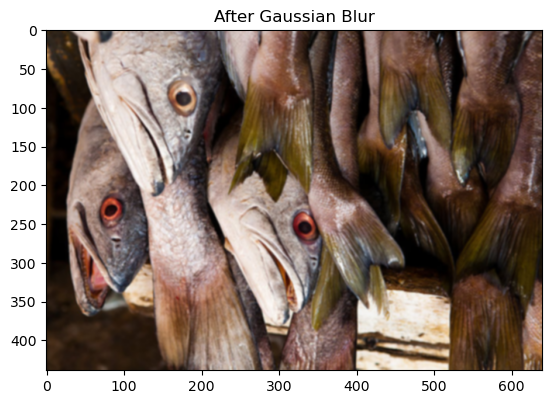

In [7]:
img = cv2.GaussianBlur(img, (3, 3), 0) # Adding Gaussian Blur with 3 x 3 filter size
display_image(img, "After Gaussian Blur")

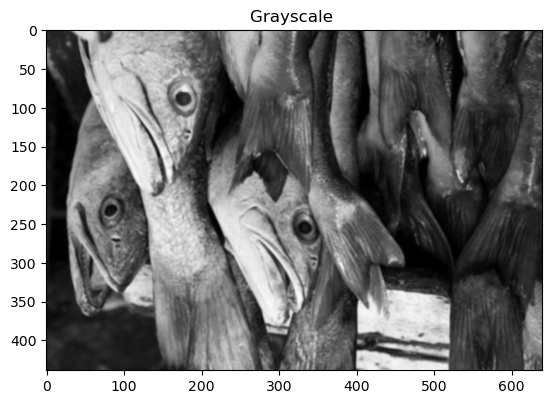

In [8]:
src_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
display_image(src_gray, "Grayscale ")

## Subtracting Original Image from Blurred Versions

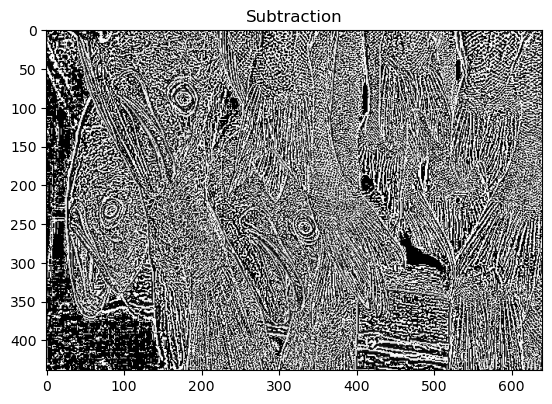

In [9]:
src_original = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
img3 = src_original - src_gray
display_image(img3, "Subtraction")

## Using Median Blur

Median Blurring takes the median of all the pixels under the kernel area and the central element is replaced with this median value. This is highly effective against salt-and-pepper noise in an image. As we have seen with Gaussian and Box filters, the central element is a newly calculated value which may not be  a pixel value in the image. But in median blurring, the central element is always replaced by some pixel value in the image.

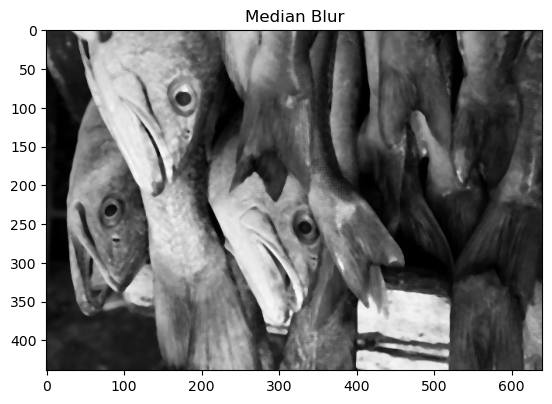

In [10]:
src_original = cv2.medianBlur(src_original, 5)
display_image(src_original, "Median Blur")

## Sobel Filter
Calculates the first, second, third, or mixed image derivatives using an extended Sobel operator. Primarily useful for detecting edges.

Parameters used:
1. src --> input image.
2. dst	--> output image of the same size and the same number of channels as src .
3. ddepth --> 	output image depth, see combinations; in the case of 8-bit input images it will result in truncated derivatives.
4. dx -->	order of the derivative x.
5. dy -->	order of the derivative y.
6. ksize -->	size of the extended Sobel kernel; it must be 1, 3, 5, or 7.
7. scale --> 	optional scale factor for the computed derivative values; by default, no scaling is applied (see getDerivKernels for details).
8. delta -->	optional delta value that is added to the results prior to storing them in dst.
9. borderType --> 	pixel extrapolation method, see BorderTypes. BORDER_WRAP is not supported.

In [11]:
scale = 1
delta = 0
ddepth = cv2.CV_16S  ## To prevent overflow
kernel_size = 3

In [12]:
grad_x = cv2.Sobel(src_gray, ddepth, 1, 0, ksize=kernel_size, scale=scale, delta=delta, borderType=cv2.BORDER_DEFAULT)
grad_y = cv2.Sobel(src_gray, ddepth, 0, 1, ksize=kernel_size, scale=scale, delta=delta, borderType=cv2.BORDER_DEFAULT)

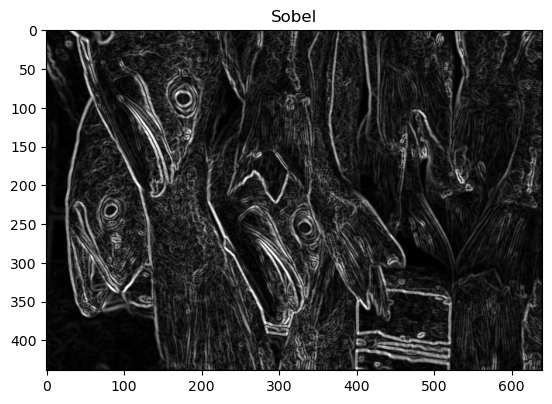

In [13]:
abs_grad_x = cv2.convertScaleAbs(grad_x)
abs_grad_y = cv2.convertScaleAbs(grad_y)

grad = cv2.addWeighted(abs_grad_x, 0.5, abs_grad_y, 0.5, 0) ## approximating gradient
display_image(grad, "Sobel")